<a href="https://colab.research.google.com/github/Bhumika2012/Bhumika2012/blob/main/MNIST_FASHION_ANN_%26_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classifying Images of Clothing**
1. **ANN Model For Fassion MNIST**
2. **CNN Model For Fassion MNIST**

# **ANN Model For Fassion MNIST**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

(X_train,Y_train),(X_test,Y_test)=tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
X_train.shape

(60000, 28, 28)

In [3]:
X_test.shape

(10000, 28, 28)

In [4]:
Y_train.shape

(60000,)

In [5]:
Y_test.shape

(10000,)

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

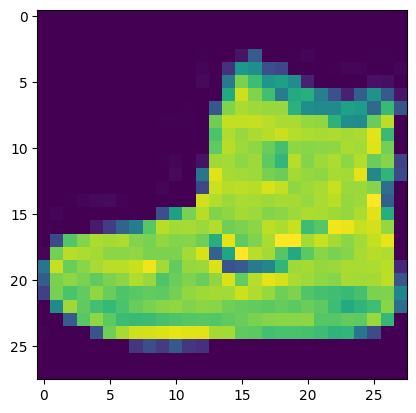

In [7]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [8]:
Y_train[0]

np.uint8(9)

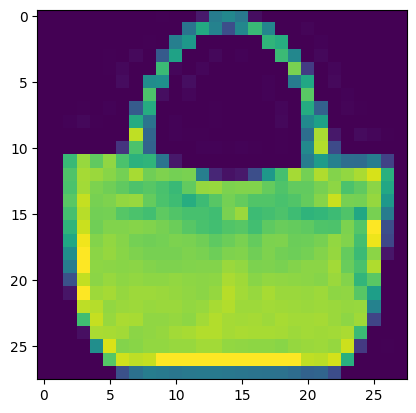

In [9]:
plt.imshow(X_train[100])

In [10]:
Y_train[100]

np.uint8(8)

In [11]:
X_train=X_train/255.0
X_test=X_test/255.0

# Reshape the input data to be flat (784 features)
X_train_df = X_train.reshape(X_train.shape[0], 784)
X_test_df = X_test.reshape(X_test.shape[0], 784)

In [12]:
ann_model = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ann_history = ann_model.fit(X_train_df,Y_train, epochs=10, validation_data=(X_test_df, Y_test))

# ANN Predictions
y_pred_ann = np.argmax(ann_model.predict(X_test_df), axis=1)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7672 - loss: 0.6586 - val_accuracy: 0.8413 - val_loss: 0.4320
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8632 - loss: 0.3767 - val_accuracy: 0.8648 - val_loss: 0.3663
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8756 - loss: 0.3344 - val_accuracy: 0.8659 - val_loss: 0.3717
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8854 - loss: 0.3074 - val_accuracy: 0.8785 - val_loss: 0.3364
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8909 - loss: 0.2906 - val_accuracy: 0.8733 - val_loss: 0.3572
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8976 - loss: 0.2798 - val_accuracy: 0.8746 - val_loss: 0.3555
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8980 - loss: 0.2716 - val_accuracy: 0.8797 - val_loss: 0.3243
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9057 - loss: 0.2548 -

In [13]:
y_pred_ann.shape

(10000,)

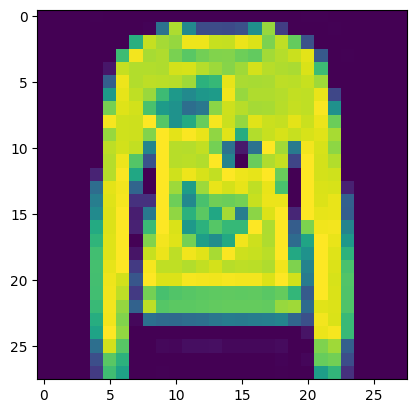

In [14]:
plt.imshow(X_test[5000])

In [15]:
Y_test[5000]

np.uint8(2)

In [16]:
y_pred_ann[5000]

np.int64(2)

0
6


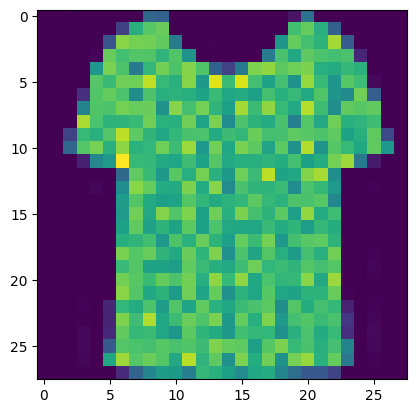

In [17]:
plt.imshow(X_test[1000])
print(Y_test[1000])
print(y_pred_ann[1000])

8
8


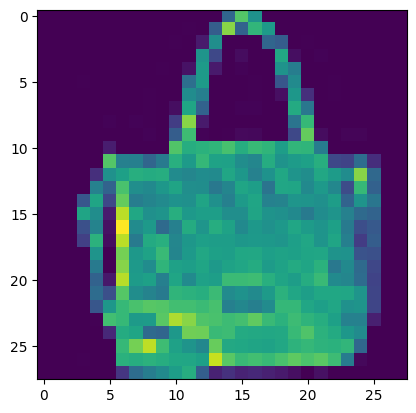

In [18]:
plt.imshow(X_test[2000])
print(Y_test[2000])
print(y_pred_ann[2000])

1
1


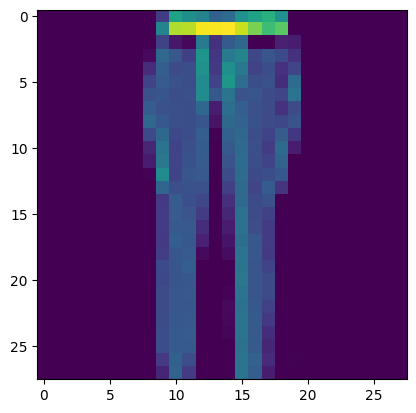

In [19]:
plt.imshow(X_test[6000])
print(Y_test[6000])
print(y_pred_ann[6000])

In [20]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


print("\n📌 ANN Classification Report:")

print(classification_report(Y_test, y_pred_ann, target_names=class_names))


📌 ANN Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.79      0.79      1000
       Dress       0.86      0.92      0.89      1000
        Coat       0.78      0.83      0.80      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.75      0.67      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



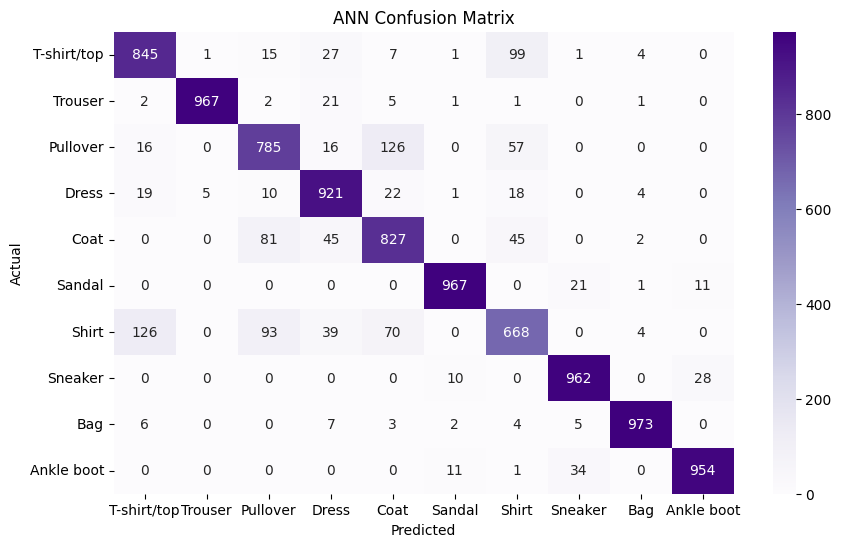

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(Y_test, y_pred_ann), annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [22]:
report_ann = classification_report(Y_test, y_pred_ann, target_names=class_names, output_dict=True)
overall_accuracy_ann = report_ann['accuracy']

print("\Overall Accuracy (ANN):",overall_accuracy_ann)

\Overall Accuracy (ANN): 0.8869


<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_529/282986300.py:4: SyntaxWarning: invalid escape sequence '\O'
  print("\Overall Accuracy (ANN):",overall_accuracy_ann)


In [23]:
# ANN Evaluation
train_acc_ann = ann_model.evaluate(X_train_df, Y_train, verbose=0)[1]
test_acc_ann = ann_model.evaluate(X_test_df, Y_test, verbose=0)[1]


print("\n ANN Train Accuracy:", train_acc_ann)
print("\n Test Accuracy:",test_acc_ann)


 ANN Train Accuracy: 0.9206333160400391

 Test Accuracy: 0.886900007724762


# **CNN Model For Fassion MNIST**

In [24]:
(X_train,Y_train),(X_test,Y_test)=tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


X_train=X_train/255.0
X_test=X_test/255.0


cnn_model = tf.keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28, 1)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),


    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cnn_history = cnn_model.fit(X_train,Y_train, epochs=10, validation_data=(X_test, Y_test))

# CNN Predictions
y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)

# CNN Evaluation
train_acc_cnn = cnn_model.evaluate(X_train, Y_train, verbose=0)[1]
test_acc_cnn = cnn_model.evaluate(X_test, Y_test, verbose=0)[1]


print("\n ANN Train Accuracy:", train_acc_ann)
print("\n Test Accuracy:",test_acc_ann)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7799 - loss: 0.6087 - val_accuracy: 0.8671 - val_loss: 0.3565
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8843 - loss: 0.3135 - val_accuracy: 0.8934 - val_loss: 0.2932
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9065 - loss: 0.2520 - val_accuracy: 0.8984 - val_loss: 0.2708
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9176 - loss: 0.2214 - val_accuracy: 0.9016 - val_loss: 0.2681
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9279 - loss: 0.1905 - val_accuracy: 0.9076 - val_loss: 0.2581
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9378 - loss: 0.1718 - val_accuracy: 0.9079 - val_loss: 0.2725
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9450 - loss: 0.1482 - val_accuracy: 0.9122 - val_loss: 0.2494
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9506 - loss: 0.1303 

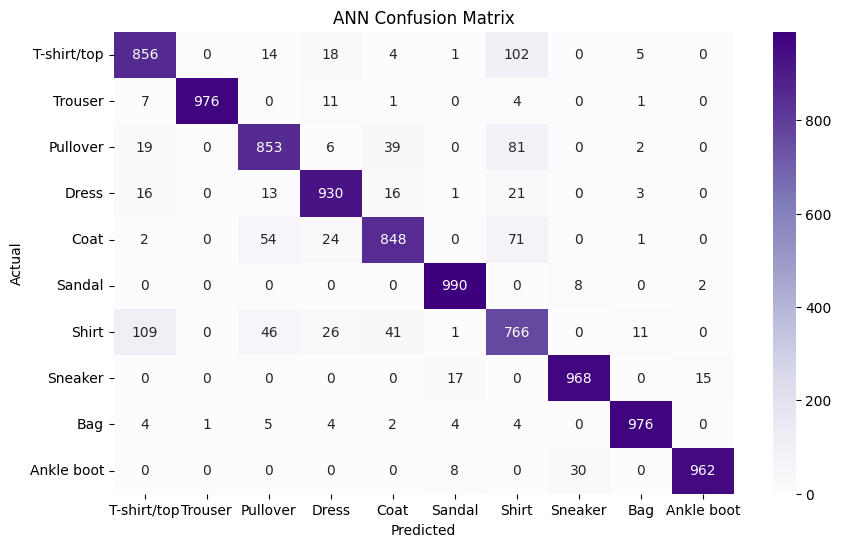

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(Y_test, y_pred_cnn), annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [27]:
report_cnn = classification_report(Y_test, y_pred_cnn, target_names=class_names, output_dict=True)
overall_accuracy_ann = report_cnn['accuracy']

print("\Overall Accuracy (ANN):",overall_accuracy_ann)

\Overall Accuracy (ANN): 0.9125


<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_529/1868830770.py:4: SyntaxWarning: invalid escape sequence '\O'
  print("\Overall Accuracy (ANN):",overall_accuracy_ann)


##**ANN Overall Accuracy 88.55 %**
##**CNN Overall Accuracy 91.55 %**